In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [16]:
df = pd.read_csv("loan_applications.csv")

df.head()

,Customer_ID,Age,Income,Loan_Amount,Credit_Score,Loan_Term,Default_Status
0,1,59,38483.02,22154.96,722,48,No
1,2,49,44140.01,12484.15,572,12,Yes
2,3,35,53518.14,16603.03,648,36,Yes
3,4,63,83469.30,34584.97,636,60,Yes
4,5,28,56298.74,23994.90,737,60,No


#Mean, Median, Mode of Income

In [17]:
mean_income = df["Income"].mean()
median_income = df["Income"].median()
mode_income = df["Income"].mode()[0]

print("Mean Income:", mean_income)
print("Median Income:", median_income)
print("Mode Income:", mode_income)

Mean Income: 60036.524304
Median Income: 60056.815
Mode Income: 20000.0


#Range, Variance, Standard Deviation (Loan Amount)

In [18]:
loan_range = df["Loan_Amount"].max() - df["Loan_Amount"].min()

loan_variance = df["Loan_Amount"].var()

loan_std = df["Loan_Amount"].std()

print("Range:", loan_range)
print("Variance:", loan_variance)
print("Standard Deviation:", loan_std)

Range: 42244.3
Variance: 63089865.555022575
Standard Deviation: 7942.912913725202


#Probability of Loan Default

In [19]:
default_prob = (df["Default_Status"] == "Yes").mean()

print("Probability of Default:", default_prob)

Probability of Default: 0.4528


#Contingency Table

In [20]:
df["Credit_Category"] = pd.cut(df["Credit_Score"],
                               bins=[300,600,700,850],
                               labels=["Poor","Average","Good"])

table = pd.crosstab(df["Credit_Category"], df["Default_Status"])

print(table)

Default_Status     No   Yes
Credit_Category            
Poor               37   579
Average          1119  1368
Good             1580   317


#Conditional Probability

In [21]:
poor_credit = df[df["Credit_Score"] < 600]

cond_prob = (poor_credit["Default_Status"] == "Yes").mean()

print("P(Default | Credit Score < 600) =", cond_prob)

P(Default | Credit Score < 600) = 0.9429530201342282


#Histogram with Gaussian Curve

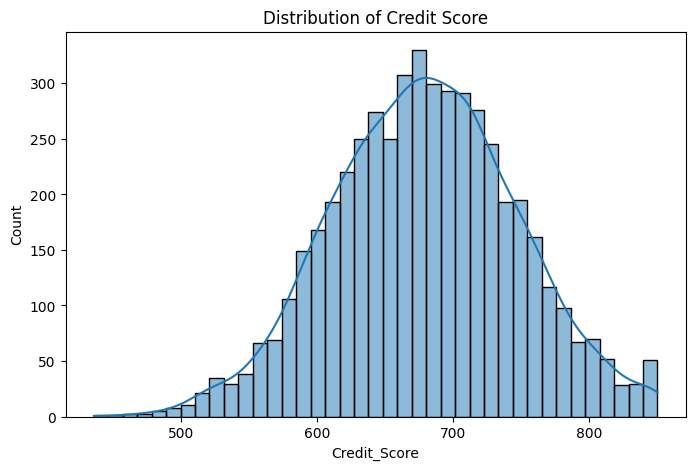

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(df["Credit_Score"], kde=True)

plt.title("Distribution of Credit Score")

plt.show()

#Skewness and Kurtosis

In [23]:
skew = df["Loan_Amount"].skew()

kurt = df["Loan_Amount"].kurt()

print("Skewness:", skew)
print("Kurtosis:", kurt)

Skewness: 0.10061959344859754
Kurtosis: -0.3239122056754349


#Q-Q Plot for Income

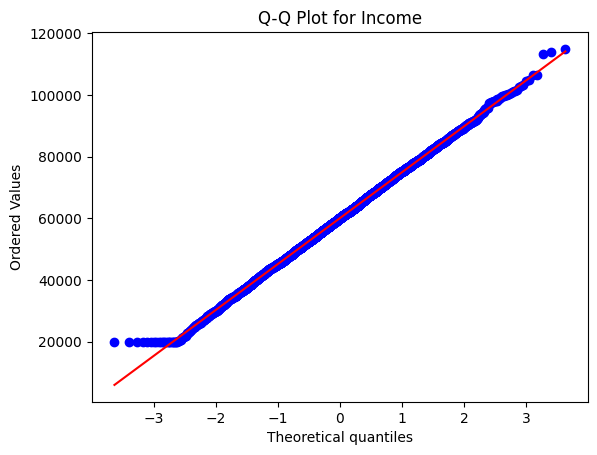

In [24]:
stats.probplot(df["Income"], dist="norm", plot=plt)

plt.title("Q-Q Plot for Income")

plt.show()

#Linear Algebra (Vectors)

In [25]:
vectors = df[["Income","Loan_Amount"]].head(5)

print(vectors)

     Income  Loan_Amount
0  38483.02     22154.96
1  44140.01     12484.15
2  53518.14     16603.03
3  83469.30     34584.97
4  56298.74     23994.90


#Dot Product

In [26]:
v1 = vectors.iloc[0].values
v2 = vectors.iloc[1].values

dot = np.dot(v1,v2)

print("Dot Product:", dot)

Dot Product: 1975226731.5142


#Norm of Vector

In [27]:
norm = np.linalg.norm(v1)

print("Norm:", norm)

Norm: 44404.786689297354


#Angle Between Two Customers

In [28]:
angle = np.arccos(dot/(np.linalg.norm(v1)*np.linalg.norm(v2)))

angle_deg = np.degrees(angle)

print("Angle between vectors:", angle_deg)

Angle between vectors: 14.136821506022477
